In [35]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

%matplotlib inline

In [17]:
import os

# Check where Python is currently looking
print("Current Working Directory:", os.getcwd())
print("Contents of CWD:", os.listdir())

# Try to see if 'data' folder exists here
if os.path.exists('data'):
    print("'data' folder found.")
    print("Contents of 'data':", os.listdir('data'))
else:
    print("'data' folder NOT found in current directory.")   

Current Working Directory: d:\PyTorch experiments\plant-disease-classifier\notebooks
Contents of CWD: ['experiments.ipynb']
'data' folder NOT found in current directory.


In [19]:
train_ds = ImageFolder(root = r'..\data\train')
val_ds = ImageFolder(root = r'..\data\valid')
# test_ds = ImageFolder(root = r'..\data\test')

In [31]:
print("Number of classes in train dataset: ", len(train_ds.classes))
print("Number of images in train dataset: ", len(train_ds.imgs))

print()

print("Number of classes in validation dataset: ", len(val_ds.classes))
print("Number of images in train dataset: ", len(val_ds.imgs))


Number of classes in train dataset:  38
Number of images in train dataset:  70295

Number of classes in validation dataset:  38
Number of images in train dataset:  17572


In [64]:
from pathlib import Path

train_dir = Path("../data/train")

classes = sorted([folder.name for folder in train_dir.iterdir() if folder.is_dir()])

print(f"Number of classes: {len(classes)}")
print(classes)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [55]:
from pathlib import Path
import pandas as pd

train_dir = Path("../data/train")

class_counts = {}

for class_dir in train_dir.iterdir():
    if class_dir.is_dir():
        class_counts[class_dir.name] = len(list(class_dir.glob("*")))

df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Images"]
).sort_values("Images", ascending=False)

df

,Class,Images
24,Soybean___healthy,2022
0,Apple___Apple_scab,2016
15,Orange___Haunglongbing_(Citrus_greening),2010
3,Apple___healthy,2008
19,"Pepper,_bell___healthy",1988
1,Apple___Black_rot,1987
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961
20,Potato___Early_blight,1939
22,Potato___Late_blight,1939
30,Tomato___healthy,1926


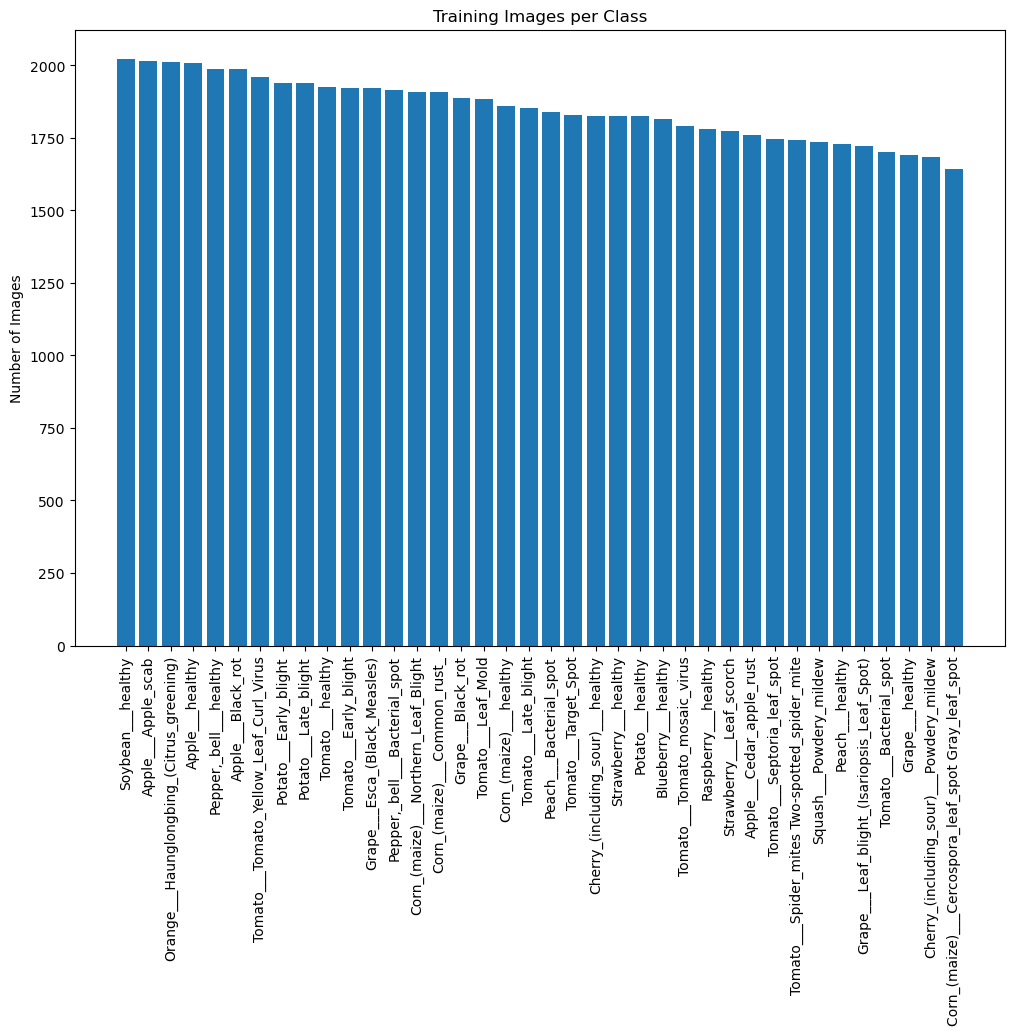

In [59]:
plt.figure(figsize=(12,8))
plt.bar(df["Class"], df["Images"])
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Training Images per Class")
plt.show()

In [60]:
from PIL import Image

image_sizes = []

for class_dir in train_dir.iterdir():
    if class_dir.is_dir():
        for image_path in class_dir.glob("*"):
            with Image.open(image_path) as img:
                image_sizes.append(img.size)   # (width, height)

In [61]:
len(set(image_sizes))

1

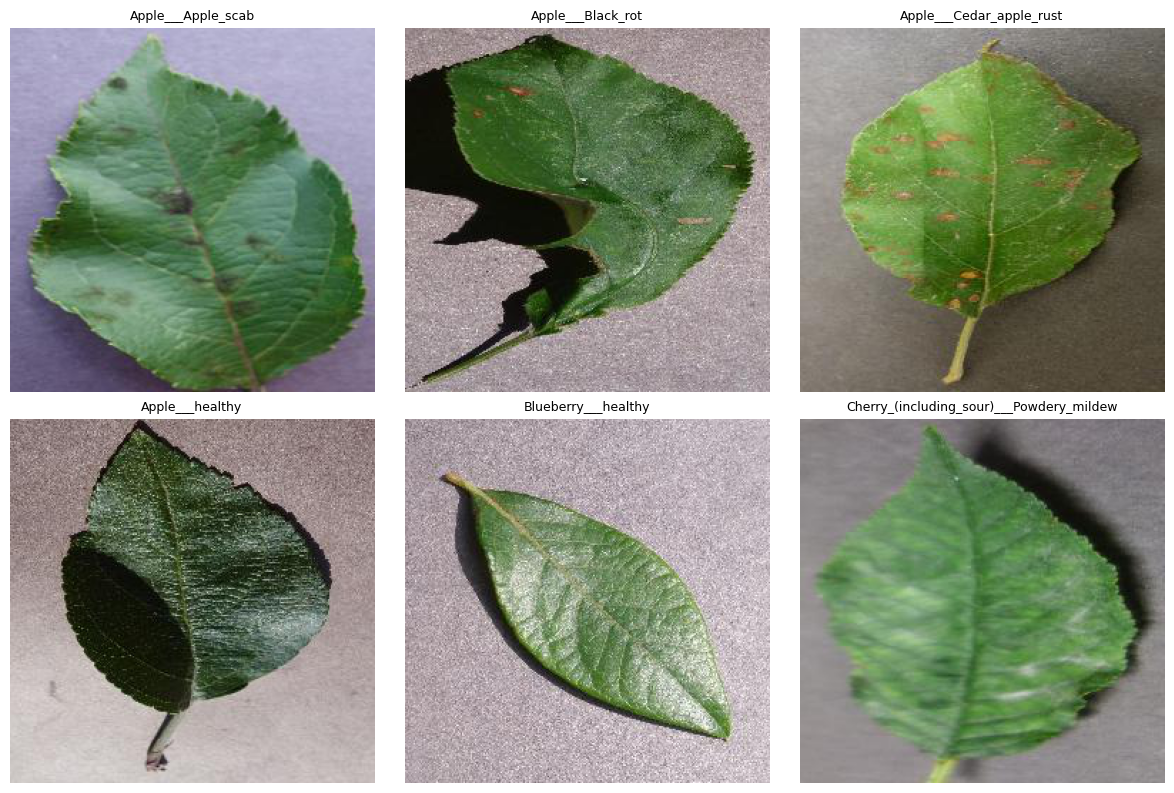

In [62]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, class_name in zip(axes.flatten(), classes[:6]):
    image_path = next((train_dir / class_name).glob("*"))
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()

In [63]:
from PIL import Image

image_path = next((train_dir / classes[0]).glob("*"))

img = Image.open(image_path)

print(img.mode)

RGB


In [65]:
print(img.size)

(256, 256)
